## Step 0 - Imports

In [18]:
# NOTE: feel free to utilize libraries that you find helpful

import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from matplotlib.pyplot import title


## Step 1 — Reproducibility + device

- **Reproducibility:** We fix random seeds so dataset shuffling, weight initialization, and dropout are as repeatable as possible across runs. This makes results comparable and debugging meaningful.

- **Determinism controls:** Setting `torch.backends.cudnn.deterministic=True` and `benchmark=False` reduces non-deterministic GPU behavior (at a potential speed cost), so you don’t “win or lose” accuracy due to hidden algorithm choices.


In [19]:
SEED: int = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [20]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


## Step 2 — Load Fashion-MNIST dataset

> Remember that in seminar we did MNIST dataset that was only for digit classification.

Now we're working with a standardized image classification benchmark: 28×28 grayscale **clothing** photos, 10 classes, with an official 60k/10k train/test split.

We'll download it without specific options to later do normalization&shuffling ourselves in order to understand how it's done.

In [21]:
CLASS_NAMES: list[str] = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


In [22]:
ds = load_dataset("fashion_mnist")  # cached under ~/.cache/huggingface/datasets by default

# Make columns come out as NumPy arrays where possible.
train_split = ds["train"].with_format("numpy")
test_split = ds["test"].with_format("numpy")


def _images_to_u8(images: object) -> np.ndarray:
    """
    The 'image' column can come back either as:
      - a single np.ndarray of shape [N, 28, 28], or
      - a list-like of [28, 28] arrays.
    Normalize it into a uint8 ndarray [N, 28, 28].
    """
    if isinstance(images, np.ndarray):
        arr = images
    else:
        arr = np.stack(images)  # works if it's list-like of 2D arrays
    return arr.astype(np.uint8)


train_images_u8 = _images_to_u8(train_split["image"])
train_labels_i64 = np.asarray(train_split["label"], dtype=np.int64)

test_images_u8 = _images_to_u8(test_split["image"])
test_labels_i64 = np.asarray(test_split["label"], dtype=np.int64)

assert train_images_u8.shape == (60_000, 28, 28)
assert train_labels_i64.shape == (60_000,)
assert test_images_u8.shape == (10_000, 28, 28)
assert test_labels_i64.shape == (10_000,)


## Step 3 — Data Visualization **[1 points]**

***Task***:

- Randomly select a small set of training examples.

- Display them as a grid of grayscale images.

- Put the class name (decoded from the numeric label) as the title for each image.

- Verify visually that:
  - the images look like clothing silhouettes (not noise/corrupted)
  - labels match what you see (e.g., sneaker vs sandal)
  - pixel orientation/contrast looks reasonable


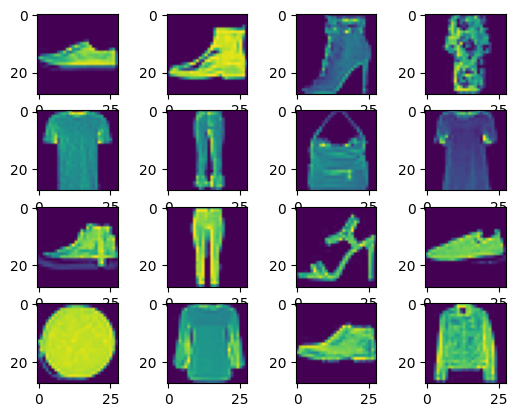

In [23]:
from itertools import product

grid_n = 16
side = int(grid_n ** 0.5)
idx = np.random.default_rng(SEED).choice(
    len(train_images_u8), size=grid_n, replace=False
)
fix, ax = plt.subplots(ncols=side, nrows=side)
for x, y in product(range(side), repeat=2):
    ax[x, y].imshow(train_images_u8[idx[x + side * y]])

## Step 4 — Train/val split + normalization **[1 points]**

***Task***:

- Create a **train/validation split** from the **shuffled (by you!)** original training set (e.g., 90% train, 10% val).

- Compute **normalization statistics (mean and std)** using **only the train split**.

- Apply the same normalization to **train, val, and test** using the train-derived mean/std.

- Add a channel dimension to get `[N, 1, 28, 28]`

    > We add a channel dimension so each sample matches the standard image tensor convention **[C, H, W]** (and batches **[N, C, H, W]**).  
    Even for grayscale, **C=1** is required so downstream layers and dataloaders can treat grayscale and RGB images uniformly.


In [24]:
val_fraction: float = 0.20

n_total = train_images_u8.shape[0]
n_val = int(n_total * val_fraction)
n_train = n_total - n_val
n_total_idxs = list(range(n_total))

np.random.default_rng(SEED).shuffle(n_total_idxs)
train_idx = n_total_idxs[:n_train]
val_idx = n_total_idxs[n_train:]

train_images = train_images_u8[train_idx]
train_labels = train_labels_i64[train_idx]
val_images = train_images_u8[val_idx]
val_labels = train_labels_i64[val_idx]

# train_images = np.expand_dims(train_images, axis=1)
# val_images = np.expand_dims(val_images, axis=1)
# train_images.shape

In [25]:
mean = train_images.mean(axis=(0, 1, 2))
std = train_images.std(axis=(0, 1, 2))
# NOTE: we need them later for denormalization also!

print(f"Normalization (computed on TRAIN split only): mean={mean:.6f}, std={std:.6f}")


def normalize_u8(images_u8: np.ndarray, mean: float, std: float) -> np.ndarray:
    """Convert uint8 images [N,28,28] -> float32 normalized [N,1,28,28]."""
    images_u8 = images_u8.astype(dtype=np.float32, copy=False)
    images_u8 -= mean
    images_u8 /= std
    images_u8 = np.expand_dims(images_u8, axis=1)
    return images_u8

Normalization (computed on TRAIN split only): mean=72.919174, std=90.031247


In [26]:
x_train = normalize_u8(train_images, mean, std)
x_val = normalize_u8(val_images, mean, std)
x_test = normalize_u8(test_images_u8, mean, std)

y_train = train_labels.astype(np.int64)
y_val = val_labels.astype(np.int64)
y_test = test_labels_i64.astype(np.int64)

x_train[0][0]

array([[-0.8099319 , -0.8099319 , -0.8099319 , -0.8099319 , -0.8099319 ,
        -0.8099319 , -0.8099319 , -0.8099319 , -0.8099319 , -0.19903283,
         0.9116927 , -0.1323893 , -0.8099319 , -0.8099319 , -0.8099319 ,
        -0.8099319 , -0.8099319 ,  0.14529206,  0.60068953, -0.8099319 ,
        -0.8099319 , -0.8099319 , -0.8099319 , -0.8099319 , -0.8099319 ,
        -0.8099319 , -0.8099319 , -0.8099319 ],
       [-0.8099319 , -0.8099319 , -0.8099319 , -0.8099319 , -0.8099319 ,
        -0.8099319 , -0.8099319 , -0.8099319 ,  1.0227652 ,  1.9224528 ,
         1.8558093 ,  1.8558093 ,  1.9335601 ,  1.3004466 ,  1.0783014 ,
         1.5114844 ,  1.9779891 ,  1.8113803 ,  1.8780239 ,  1.5448061 ,
        -0.49892873, -0.8099319 , -0.7988246 , -0.8099319 , -0.8099319 ,
        -0.8099319 , -0.8099319 , -0.8099319 ],
       [-0.8099319 , -0.8099319 , -0.8099319 , -0.8099319 , -0.8099319 ,
        -0.8099319 , -0.8099319 , -0.4322852 ,  1.9113456 ,  1.666986  ,
         1.6780932 ,  1.6669

## Step 5 — Dataset + DataLoaders **[1 points]**

***Task***:

- Wrap `(x, y)` arrays into a custom `Dataset` that:
  - validates shapes (`x: [N,C,H,W]`, `y: [N]`):
    - validate `x` shape
    - validate `y` shape
    - validate that they length match

  - wraps `(x, y)` into `torch.Tensor`

  - returns one `(image_tensor, label_tensor)` per index

- Create `DataLoader`s for train/val/test that:
  - batch samples (set `batch_size`)

  - shuffle _only_ the training loader

  - enable `pin_memory` when using CUDA for faster host $\to$ GPU transfers


In [27]:
from torch.utils.data import Dataset, DataLoader


class FashionMNISTFromNumpy(Dataset[tuple[torch.Tensor, torch.Tensor]]):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        assert len(x.shape) == 4, f"X should has shape (N, C, H, W), but got {x.shape} dims"
        assert len(y.shape) == 1, f"y shuld be 1-dim array, but got {y.shape} dims"
        self.x = torch.from_numpy(x)
        self.y = torch.from_numpy(y)

    def __len__(self) -> int:
        return self.y.shape[0]

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.x[index], self.y[index]


train_ds = FashionMNISTFromNumpy(x_train, y_train)
val_ds = FashionMNISTFromNumpy(x_val, y_val)
test_ds = FashionMNISTFromNumpy(x_test, y_test)

batch_size: int = 256
pin_memory: bool = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)
test_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_memory)

## Step 6 — Model + loss + optimizer **[1 points]**

***Task:***

- Create your classifier (start with some simple baseline) appropriate for 28×28 images:
  - **linear (logistic regression)** on flattened pixels *<[good for baseline]>*

  - **MLP(FFN)** on flattened pixels with `nn.Dropout` & `nn.BatchNorm` *<[our seminar choice]>*:
    - here you can use `nn.Linear`, `nn.ReLU`, `nn.Dropout`, `nn.BatchNorm`, maybe try to use `nn.Sequential` for easier way of work

  - **CNN** *<[if you soooo cool and bored with MLP and ready to learn something new yourself!]>*:
    - here you can use `nn.Conv2d`, `nn.MaxPool2d`

    - > NOTE: for using CNN you _won't_ get any additional points, so if you're new to DL, stick to MLP

- Use `nn.CrossEntropyLoss` for 10-way classification (raw logits, no softmax in the model).

- Use an optimizer that works well out of the box (maybe `Adam` will do the thing)

- Start with reasonable hyperparameters:
  - learning rate: remember of how we came up with learning rate value in seminar class using ideas of normalization of data and normalization _within_ our NN

  - maybe try out **weight decay** (which is direct way of doing regularization, like LASSO or RIDGE in simple linear regression)

- Move model (and later batches) to the selected device (`cpu`/`cuda`) using `.to(device)`.


In [28]:
n_classes = len(np.unique(y_train))

In [29]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW


class Classifier(nn.Module):
    def __init__(self, in_features: int, n_classes: int, in_channels: int = 1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.dropout = nn.Dropout(p=0.5)

        self.fc1 = nn.Linear(400, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = F.relu(x)

        x = self.dropout(x)
        x = self.fc2(x)

        return x


model = Classifier(in_features=28 * 28, n_classes=n_classes, in_channels=1).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

## Step 7 — Metrics helpers **[1 points]**

***Task:***

- Implement a confusion-matrix accumulator that:
  - converts logits to predicted labels (`argmax`)

  - counts `(true, pred)` pairs into an `[K, K]` matrix

  - can be summed across batches to cover the full split

- Implement metric computation from the confusion matrix:
  - compute per-class precision/recall/F1

  - compute overall accuracy

  - compute macro-F1 (mean over classes)

Make these utilities `no_grad`-safe and numerically safe (avoid division by zero).


In [30]:
np.sum(y_train[y_train == 1] == 1)

np.int64(4865)

In [31]:
@torch.no_grad()
def confusion_matrix_from_logits(
        logits: torch.Tensor,
        targets: torch.Tensor,
        n_classes: int,
) -> torch.Tensor:
    """
    Build a confusion matrix from model logits and integer targets.

    Args:
        logits: Tensor of shape [B, n_classes] containing unnormalized class scores.
        targets: Tensor of shape [B] containing ground-truth class indices in [0, n_classes-1].
        n_classes: Total number of classes.

    Returns:
        Confusion matrix - a tensor of shape [n_classes, n_classes] with dtype int64, where:
          - rows correspond to true classes
          - columns correspond to predicted classes
        Entry cm[i, j] is the number of samples with true class i predicted as class j.

    Notes:
        Runs under no-grad (evaluation utility). Computation is performed on CPU for counting.
    """
    preds = torch.argmax(logits, dim=1).view(-1).to("cpu")
    t = targets.view(-1).to("cpu")

    cm = torch.zeros(size=(n_classes, n_classes))

    for i in range(n_classes):
        for j in range(n_classes):
            cm[i, j] = torch.sum(preds[t == i] == j)

    return cm


def metrics_from_confusion_matrix(cm: torch.Tensor) -> dict[str, object]:
    """
    Compute classification metrics from a confusion matrix.

    Args:
        cm: Confusion matrix tensor of shape [n_classes, n_classes] with nonnegative counts,
            where rows are true classes and columns are predicted classes.

    Returns:
        Dictionary with:
          - "accuracy": float, overall accuracy (sum(diagonal) / sum(all))
          - "macro_f1": float, mean of per-class F1 scores (uniform class weighting)
          - "precision_per_class": list[float], per-class precision
          - "recall_per_class": list[float], per-class recall
          - "f1_per_class": list[float], per-class F1
          - "support_per_class": list[int], number of true samples per class (row sums)
          - "confusion_matrix": list[list[int]], cm converted to nested Python lists

    Notes:
        Uses clamping / epsilon safeguards to avoid division-by-zero when a class has zero
        support (no true samples) or zero predicted count (never predicted).
    """
    cm_f = cm.float()
    diag = torch.diag(cm_f)
    support = cm_f.sum(dim=1).clamp_min(1.0)
    pred_count = cm_f.sum(dim=0).clamp_min(1.0)

    precision = (diag / pred_count).cpu().numpy()
    recall = (diag / support).cpu().numpy()
    f1 = 2 * (precision * recall) / (precision + recall)
    macro_f1 = float(np.mean(f1))

    accuracy = diag.sum() / cm_f.sum()

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "precision_per_class": precision.tolist(),
        "recall_per_class": recall.tolist(),
        "f1_per_class": f1.tolist(),
        "support_per_class": cm.sum(dim=1).tolist(),
        "confusion_matrix": cm.tolist(),
    }

## Step 8 — Train with per-epoch validation + live visualization **[3 points]**

***Task:***

- Run training for a fixed number of epochs.

- For each epoch:
  - **Training phase:** set `model.train()`, iterate over `train_loader`, do forward → loss → backward → optimizer step, accumulate average train loss and train accuracy.

  - **Validation phase:** set `model.eval()` and `torch.no_grad()`, iterate over `val_loader`, compute average val loss and val accuracy.

- Store per-epoch metrics in lists (loss/accuracy for train and val).

- After each epoch:
  - Update plots of:
    - train vs val **loss**
    - train vs val **accuracy**
    using `clear_output(wait=True)` so the curves refresh in-place.

  - Print a compact epoch summary line with the tracked metrics.


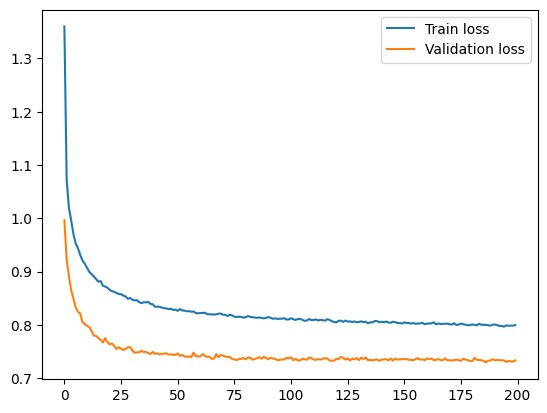

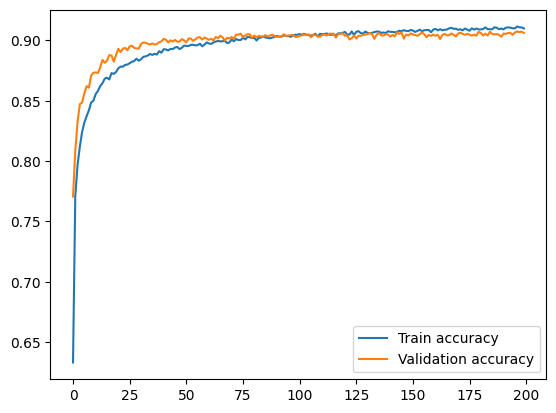

In [32]:
epochs: int = 200

train_losses: list[float] = []
val_losses: list[float] = []
train_accs: list[float] = []
val_accs: list[float] = []

for epoch in range(1, epochs + 1):
    train_loss, val_loss = 0, 0
    correct, total = 0, 0
    model.train()
    for batch in train_loader:
        x, y = batch
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        train_loss += loss.item()
        # train_acc += (y == torch.argmax(logits, dim=1).view(-1)).sum().item()
        _, predicted = torch.max(logits, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

        loss.backward()
        optimizer.step()

    train_losses.append(train_loss / len(train_loader))
    train_accs.append(correct / total)
    correct, total = 0, 0

    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            x, y = batch
            x, y = x.to(device), y.to(device)
            logits = model(x)
            _, predicted = torch.max(logits, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)
            loss = criterion(logits, y)

            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)

plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.show()
plt.plot(train_accs, label='Train accuracy')
plt.plot(val_accs, label='Validation accuracy')
plt.legend()
plt.show()

## Step 9 — Test evaluation **[0.5 points]**

***Task:***

- Switch to evaluation mode: `model.eval()` and disable gradients with `with torch.no_grad(): ...`.

- Iterate over `test_loader` once and compute:
  - average **test loss**

  - total **confusion matrix** accumulated across all batches

- From the final confusion matrix, compute and report:
  - overall **accuracy**

  - **macro-F1**

  - per-class **precision/recall/F1** and **support**

- Print the confusion matrix (rows=true, cols=pred) for error analysis.

In [33]:
n_classes = len(CLASS_NAMES)

model.eval()
cm = torch.zeros((n_classes, n_classes), dtype=torch.float64)
test_loss_sum = 0.0
test_n = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        b = x.shape[0]
        test_loss_sum += float(loss.item()) * b
        test_n += b

        cm += confusion_matrix_from_logits(logits, y, n_classes=n_classes)

test_loss = test_loss_sum / max(1, test_n)
m = metrics_from_confusion_matrix(cm)

In [34]:
print("\nTest evaluation")
print(f"  loss:     {test_loss:.6f}")
print(f"  accuracy: {float(m['accuracy']):.6f}")
print(f"  macro_f1: {float(m['macro_f1']):.6f}")

print("\nPer-class metrics:")
for k in range(n_classes):
    p = float(m["precision_per_class"][k])
    r = float(m["recall_per_class"][k])
    f1 = float(m["f1_per_class"][k])
    sup = int(m["support_per_class"][k])
    print(
        f"  class {k:02d} ({CLASS_NAMES[k]:>11s}) | P={p:.4f} R={r:.4f} F1={f1:.4f} support={sup}"
    )

print("\nConfusion matrix (rows=true, cols=pred):")
print(np.array(m["confusion_matrix"], dtype=np.int64))


Test evaluation
  loss:     0.680987
  accuracy: 0.933625
  macro_f1: 0.933406

Per-class metrics:
  class 00 (T-shirt/top) | P=0.9025 R=0.8923 F1=0.8974 support=4826
  class 01 (    Trouser) | P=0.9946 R=0.9831 F1=0.9888 support=4865
  class 02 (   Pullover) | P=0.9010 R=0.8911 F1=0.8960 support=4821
  class 03 (      Dress) | P=0.9161 R=0.9462 F1=0.9309 support=4744
  class 04 (       Coat) | P=0.8802 R=0.8970 F1=0.8885 support=4768
  class 05 (     Sandal) | P=0.9887 R=0.9906 F1=0.9897 support=4786
  class 06 (      Shirt) | P=0.8091 R=0.7942 F1=0.8016 support=4777
  class 07 (    Sneaker) | P=0.9746 R=0.9762 F1=0.9754 support=4793
  class 08 (        Bag) | P=0.9856 R=0.9865 F1=0.9861 support=4801
  class 09 ( Ankle boot) | P=0.9813 R=0.9780 F1=0.9796 support=4819

Confusion matrix (rows=true, cols=pred):
[[4306    1   59   88    9    1  340    0   22    0]
 [   3 4783    1   61    8    0    8    0    1    0]
 [  36    3 4296   43  233    0  201    0    9    0]
 [  45   10   16 44

## Step 10 — Show example classifications **[1.5 points]**

***Task:***

- Randomly pick a small set of test indices (e.g., 12).

- Build a batch from those samples and run a forward pass in `model.eval()` + `torch.no_grad()`.

- Convert logits to:
  - predicted class (`argmax`)

  - confidence (max softmax probability)

- Visualize the selected images in a grid:
  - display the image in original pixel space (invert normalization for plotting)

  - title each with **true label**, **predicted label**, and **confidence**

  - color the title by correctness (correct vs incorrect) to spot patterns quickly

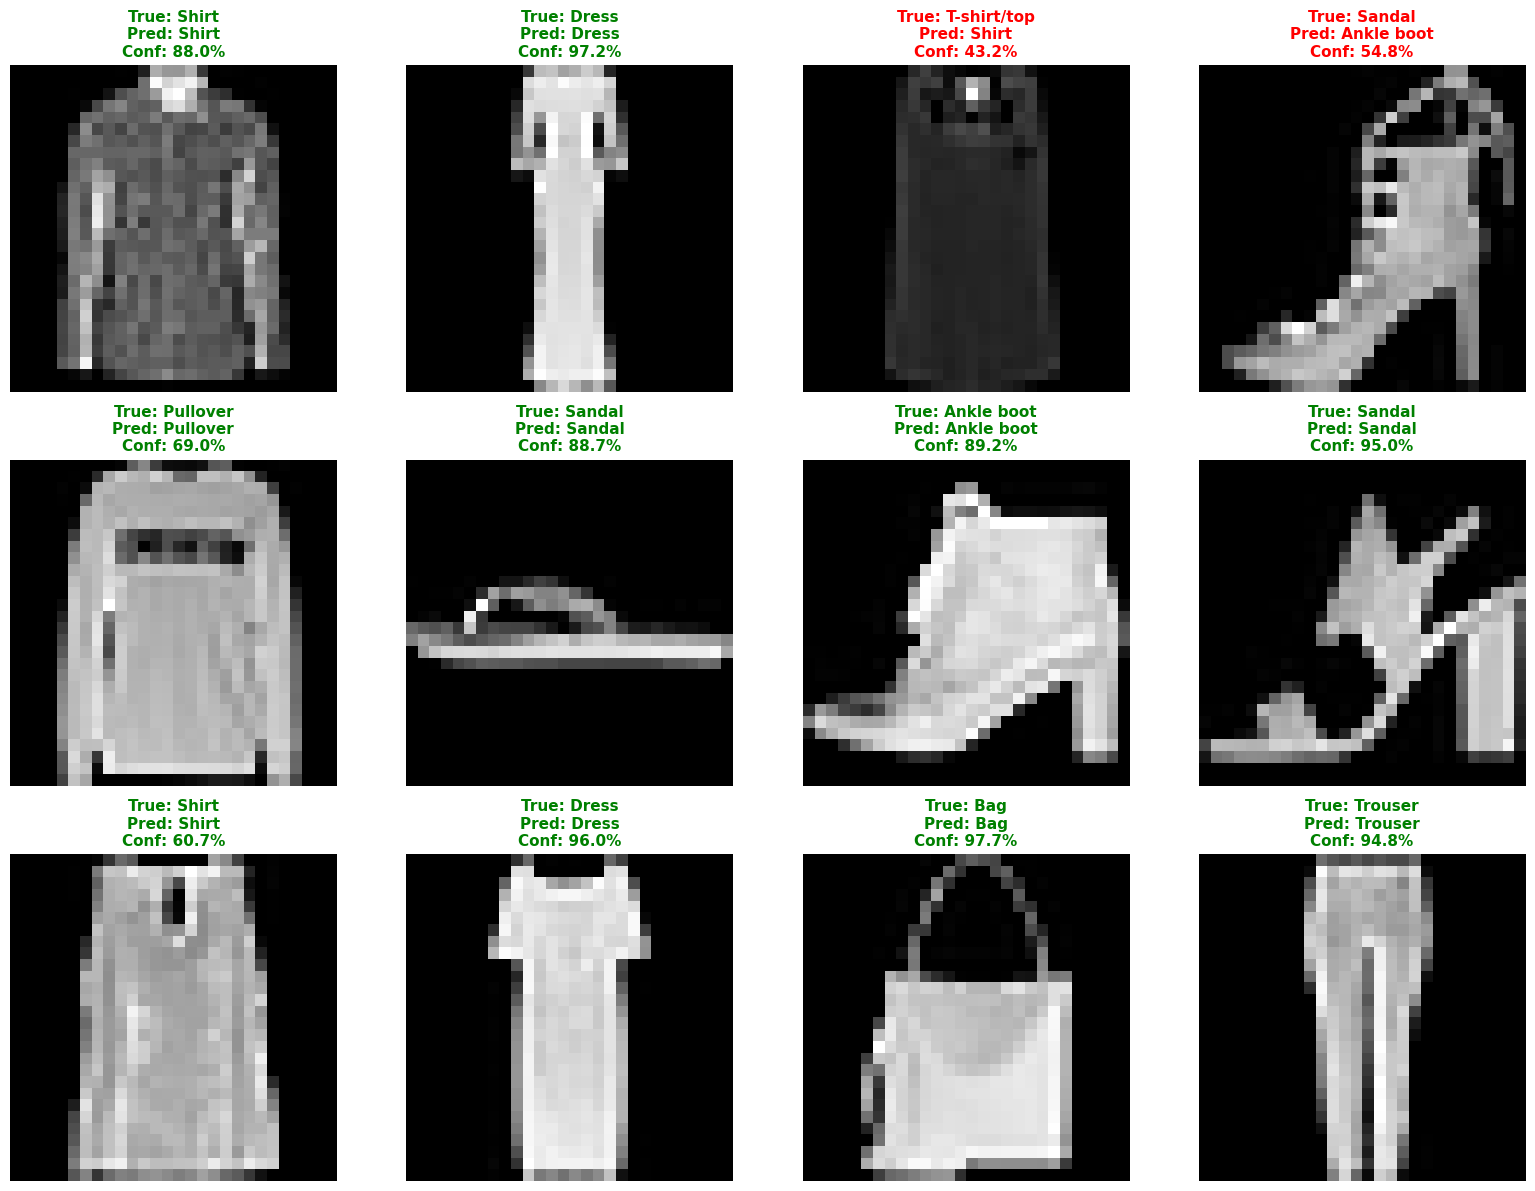

In [35]:
n_view = 12

indices = np.random.choice(len(x_test), size=n_view, replace=False)
batch_x_np = x_test[indices]
batch_y_np = y_test[indices]

batch_x = torch.from_numpy(batch_x_np).to(device)

model.eval()
with torch.no_grad():
    logits = model(batch_x)
    probs = F.softmax(logits, dim=1)
    confidences, preds = torch.max(probs, dim=1)

preds = preds.cpu().numpy()
confidences = confidences.cpu().numpy()

rows = int(np.ceil(n_view / 4))
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= n_view:
        ax.axis('off')
        continue

    img_norm = batch_x_np[i]
    img_denorm = (img_norm * std) + mean

    img_disp = img_denorm.squeeze(0)

    img_disp = np.clip(img_disp, 0, 255)

    true_label_idx = batch_y_np[i]
    pred_label_idx = preds[i]
    confidence = confidences[i]

    is_correct = (true_label_idx == pred_label_idx)
    color = 'green' if is_correct else 'red'

    title_text = (
        f"True: {CLASS_NAMES[true_label_idx]}\n"
        f"Pred: {CLASS_NAMES[pred_label_idx]}\n"
        f"Conf: {confidence:.1%}"
    )

    ax.imshow(img_disp, cmap='gray')
    ax.set_title(title_text, color=color, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 8 — Save Model Weights

Save the learned parameters so we can use them later.

In [36]:
import os

save_path = 'model_weights.pth'
torch.save(model.state_dict(), save_path)
print(f"Model weights successfully saved to {save_path}")

Model weights successfully saved to model_weights.pth
